# Imports

In [1]:
from langgraph.graph import StateGraph, START, END
# from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

# Loading env variables

In [2]:
load_dotenv()

True

# Define LLM

In [ ]:
# model = ChatOpenAI()
model = ChatGroq(model="llama-3.3-70b-versatile")

# Define State

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

# Creating Nodes

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

# Define and Compile Graph

In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


# Execute the Graph

In [8]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'Here is a detailed outline for a blog on the topic "Rise of AI in India":\n\n**I. Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Context: India\'s emergence as a significant player in the global tech industry\n* Thesis statement: India is experiencing a significant rise in the adoption and development of AI, driven by government initiatives, technological advancements, and a growing talent pool.\n\n**II. Current State of AI in India**\n\n* Overview of the current AI landscape in India, including:\n\t+ Key industries adopting AI (e.g., healthcare, finance, manufacturing)\n\t+ Notable AI-powered startups and companies in India (e.g., Flipkart, Paytm, Ola)\n\t+ Government initiatives and policies supporting AI development (e.g., National AI Strategy, AI Task Force)\n* Statistics and trends:\n\t+ Growth of AI market in India\n\t+ Increasing investment in AI startups\n\t+ Rising demand fo

In [9]:
print(final_state['outline'])

Here is a detailed outline for a blog on the topic "Rise of AI in India":

**I. Introduction**

* Brief overview of Artificial Intelligence (AI) and its growing importance globally
* Context: India's emergence as a significant player in the global tech industry
* Thesis statement: India is experiencing a significant rise in the adoption and development of AI, driven by government initiatives, technological advancements, and a growing talent pool.

**II. Current State of AI in India**

* Overview of the current AI landscape in India, including:
	+ Key industries adopting AI (e.g., healthcare, finance, manufacturing)
	+ Notable AI-powered startups and companies in India (e.g., Flipkart, Paytm, Ola)
	+ Government initiatives and policies supporting AI development (e.g., National AI Strategy, AI Task Force)
* Statistics and trends:
	+ Growth of AI market in India
	+ Increasing investment in AI startups
	+ Rising demand for AI talent

**III. Drivers of AI Growth in India**

* **Government S

In [10]:
print(final_state['content'])

**The Rise of AI in India: Unlocking a New Era of Growth and Innovation**

Artificial Intelligence (AI) has revolutionized the world, transforming the way we live, work, and interact with each other. As a significant player in the global tech industry, India is experiencing a remarkable rise in the adoption and development of AI. Driven by government initiatives, technological advancements, and a growing talent pool, India is poised to become a leader in the global AI landscape. In this blog, we will explore the current state of AI in India, its drivers, applications, challenges, and opportunities, and what the future holds for this emerging technology.

**Current State of AI in India**

India's AI landscape is rapidly evolving, with key industries such as healthcare, finance, and manufacturing adopting AI solutions to improve efficiency, productivity, and decision-making. Notable AI-powered startups and companies in India, such as Flipkart, Paytm, and Ola, are leveraging AI to enhance

# Visualize Graph (Optional)

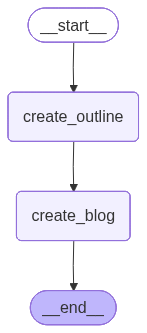

In [11]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())